# **ECG Anomaly Detection using Variational Autoencoders (VAE)**

This project focuses on detecting anomalies in ECG (electrocardiogram) signals using a Variational Autoencoder (VAE). The model is trained on normal heartbeats and identifies abnormal patterns based on reconstruction error.

The goal is to simulate a real-world healthcare use case where abnormal cardiac signals need to be detected automatically and efficiently.

In [ ]:
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split


## **Problem Statement**

ECG signals are used to monitor heart activity and detect abnormalities. Manual analysis is time-consuming and error-prone.

This project builds an automated anomaly detection system using deep learning. A Variational Autoencoder (VAE) is trained on normal ECG signals and detects anomalies based on reconstruction error.

**Dataset Loading and Extraction**

In [ ]:
# Unzip

with zipfile.ZipFile("ECG5000.zip", "r") as zip_ref:
    zip_ref.extractall("ecg_data")
print("Extracted ECG5000.zip")

# Load ECG5000 dataset and combine
train_data = np.loadtxt("ecg_data/ECG5000_TRAIN.txt")
test_data = np.loadtxt("ecg_data/ECG5000_TEST.txt")
data = np.vstack((train_data, test_data))


Extracted ECG5000.zip


## **Data Characteristics**

- The ECG5000 dataset includes **5,000 samples**, each a **1D signal with 140 time steps**  
- **Class 1** represents normal heartbeats, while **Classes 2–5** are different types of anomalies  
- This is **signal-based, non-tabular data**.


**Splitting Features and Labels**

In [ ]:
# Split into features (X) and labels (y)
X = data[:, 1:]
y = data[:, 0]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 140)
y shape: (5000,)


## **Data Preprocessing**

- ECG signals were **normalized** between 0 and 1 using `MinMaxScaler`  
- Labels were **converted to binary**:  
   Class 1 → 0 (Normal)  
   Classes 2–5 → 1 (Anomaly)  
- Only normal samples were used to train the VAE  
- Data was converted into **PyTorch tensors**, and a **DataLoader** was created for training


**Normalization, label binarization, tensor conversion, and DataLoader creation**

In [ ]:
###
# Normalize and binarize labels
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Correct label mapping: 1 = anomaly, 0 = normal
y_binary = (y != 1).astype(int)

# Use only normal samples for VAE training
X_normal = X_scaled[y_binary == 0]

###
# Convert to tensors
X_tensor = torch.tensor(X_normal, dtype=torch.float32)
X_all_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_binary, dtype=torch.int)

###
# Create DataLoader
dataset = TensorDataset(X_tensor)
train_size = int(0.8 * len(dataset))
train_dataset, _ = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

###
print("X_normal shape:", X_normal.shape)
print("X_tensor shape:", X_tensor.shape)
print("y_binary shape:", y_binary.shape)
print("Train set size:", len(train_loader.dataset))


X_normal shape: (2919, 140)
X_tensor shape: torch.Size([2919, 140])
y_binary shape: (5000,)
Train set size: 2335


## **Model Architecture**

A **Variational Autoencoder (VAE)** is used because it supports **unsupervised learning**, which is ideal for situations where labeled anomalies are limited or unavailable like in ECG signal datasets.

Instead of classifying signals directly, the VAE is trained to reconstruct only **normal ECG patterns**. Its ability to learn compressed latent representations helps it focus on the true structure of clean heartbeats. At test time, **abnormal signals** are reconstructed poorly, resulting in **high reconstruction error**, which becomes a useful signal for anomaly detection.

###Model Design Summary:
- The model uses **Mean Squared Error (MSE)** loss, which aligns well with the continuous nature of ECG signals.
- **Gaussian noise** is applied during training to encourage robustness and generalization.
- A **latent dimension of 100** helps capture subtle ECG variations in normal heartbeats without overfitting.
- The architecture is built with **linear layers and ReLU activations**, forming a standard encoder–decoder VAE structure.



**VAE Model Architecture (Encoder + Decoder)**

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=140, hidden_dim=128, latent_dim=100):  # Increased capacity
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


# Instantiate model
model = VAE()
print(model)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=140, out_features=128, bias=True)
    (1): ReLU()
  )
  (mu_layer): Linear(in_features=128, out_features=100, bias=True)
  (logvar_layer): Linear(in_features=128, out_features=100, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=140, bias=True)
  )
)


**Loss Function and Model Setup**

In [ ]:
###
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)

###
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

###
def loss_function(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

print("Device:", device)
print("Model ready with", sum(p.numel() for p in model.parameters()), "parameters.")


Device: cpu
Model ready with 74836 parameters.


**Training the Model**

In [ ]:
def train(model, loader, epochs=30):
    model.train()
    history = []
    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            x = batch[0].to(device)
            optimizer.zero_grad()
            noise = 0.01 * torch.randn_like(x)       # Add slight Gaussian noise
            x_noisy = x + noise
            recon, mu, logvar = model(x_noisy)       # Feed noisy version into model
            loss = loss_function(recon, x, mu, logvar)  # Compare to clean target
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader.dataset)
        history.append(avg_loss)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f}")
    return history
losses = train(model, train_loader)


Epoch 1 - Loss: 18.1948
Epoch 2 - Loss: 4.5038
Epoch 3 - Loss: 3.1977
Epoch 4 - Loss: 2.5309
Epoch 5 - Loss: 2.1466
Epoch 6 - Loss: 1.9007
Epoch 7 - Loss: 1.7259
Epoch 8 - Loss: 1.5553
Epoch 9 - Loss: 1.4579
Epoch 10 - Loss: 1.3385
Epoch 11 - Loss: 1.2739
Epoch 12 - Loss: 1.1708
Epoch 13 - Loss: 1.1107
Epoch 14 - Loss: 1.0734
Epoch 15 - Loss: 1.0170
Epoch 16 - Loss: 0.9690
Epoch 17 - Loss: 0.9402
Epoch 18 - Loss: 0.9001
Epoch 19 - Loss: 0.8688
Epoch 20 - Loss: 0.8397
Epoch 21 - Loss: 0.8254
Epoch 22 - Loss: 0.8004
Epoch 23 - Loss: 0.7864
Epoch 24 - Loss: 0.7681
Epoch 25 - Loss: 0.7607
Epoch 26 - Loss: 0.7458
Epoch 27 - Loss: 0.7400
Epoch 28 - Loss: 0.7301
Epoch 29 - Loss: 0.7212
Epoch 30 - Loss: 0.7163


**Visualize Training Loss**

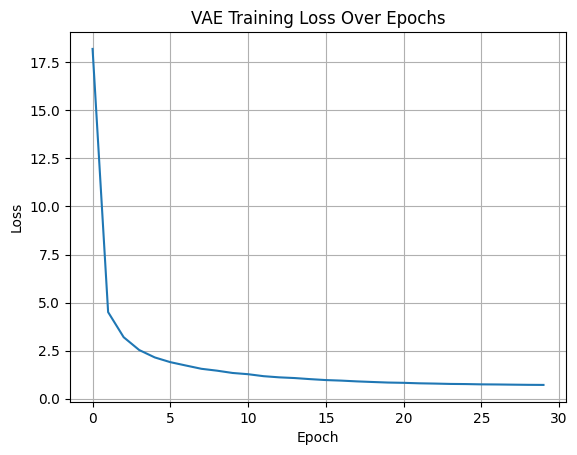

In [ ]:
# Plot loss
plt.plot(losses)
plt.title("VAE Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## **Evaluation**

The model is evaluated using both visualizations and quantitative metrics:

- **Original vs Reconstructed Signals**: Visually compare how well the VAE reconstructs input ECGs
- **Reconstruction Error Histogram**: Shows separation between normal and anomalous signals
- **ROC Curve & AUC**: AUC score of 0.97 confirms strong anomaly detection performance
- **t-SNE Plot**: Visualizes how normal and abnormal signals are separated in the learned latent space
- **Confusion Matrix**: High true positive and true negative counts
- **Classification Report**: High F1-score (0.94) and strong precision/recall

**Reconstructed vs Original ECG Signals**

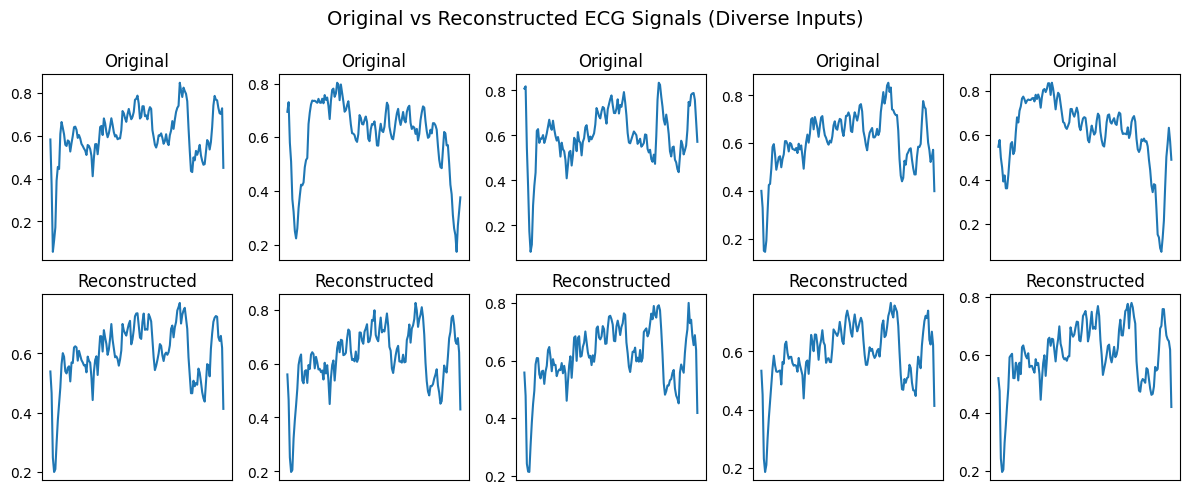

In [ ]:
# Mix normal and abnormal samples for visual testing
mixed_sample_indices = [10, 400, 1500, 3000, 4900]
x_sample_mixed = X_all_tensor[mixed_sample_indices].to(device)

model.eval()
with torch.no_grad():
    x_recon_mixed, _, _ = model(x_sample_mixed)

# Plot original vs reconstructed
plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.plot(x_sample_mixed[i].cpu().numpy())
    plt.title("Original")
    plt.xticks([])

    plt.subplot(2, 5, i + 6)
    plt.plot(x_recon_mixed[i].cpu().numpy())
    plt.title("Reconstructed")
    plt.xticks([])


plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.suptitle("Original vs Reconstructed ECG Signals (Diverse Inputs)", fontsize=14)
plt.show()


**Histogram of Reconstruction Errors**

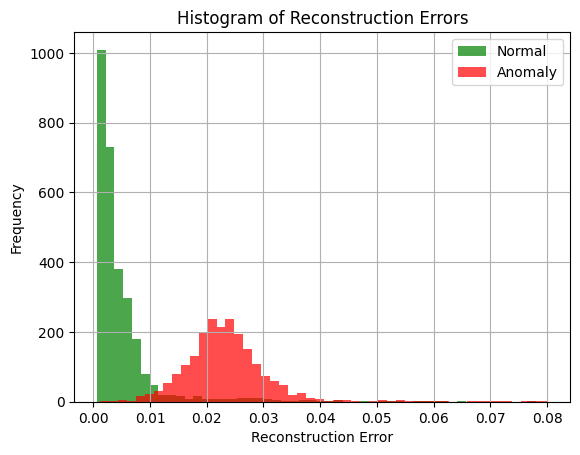

In [ ]:


with torch.no_grad():
    recon_all, _, _ = model(X_all_tensor.to(device))
    recon_all = recon_all.cpu().numpy()

recon_errors = np.mean((X_all_tensor.numpy() - recon_all) ** 2, axis=1)
normal_errors = recon_errors[y_binary == 0]
anomaly_errors = recon_errors[y_binary == 1]

plt.hist(normal_errors, bins=50, alpha=0.7, label="Normal", color="green")
plt.hist(anomaly_errors, bins=50, alpha=0.7, label="Anomaly", color="red")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Histogram of Reconstruction Errors")
plt.legend()
plt.grid(True)
plt.show()


**ROC Curve and AUC Score**

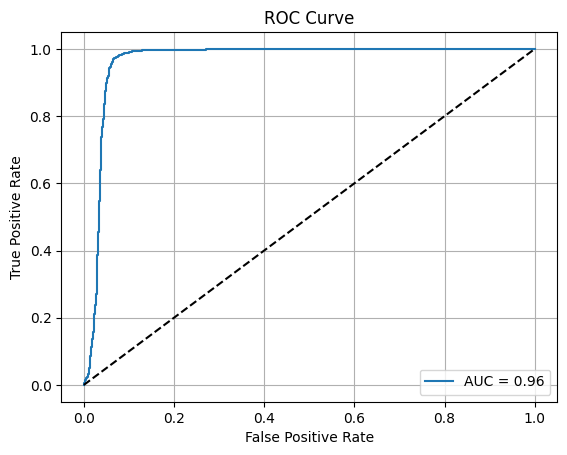

In [ ]:
fpr, tpr, _ = roc_curve(y_binary, recon_errors)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


**t-SNE Visualization of Latent Space**

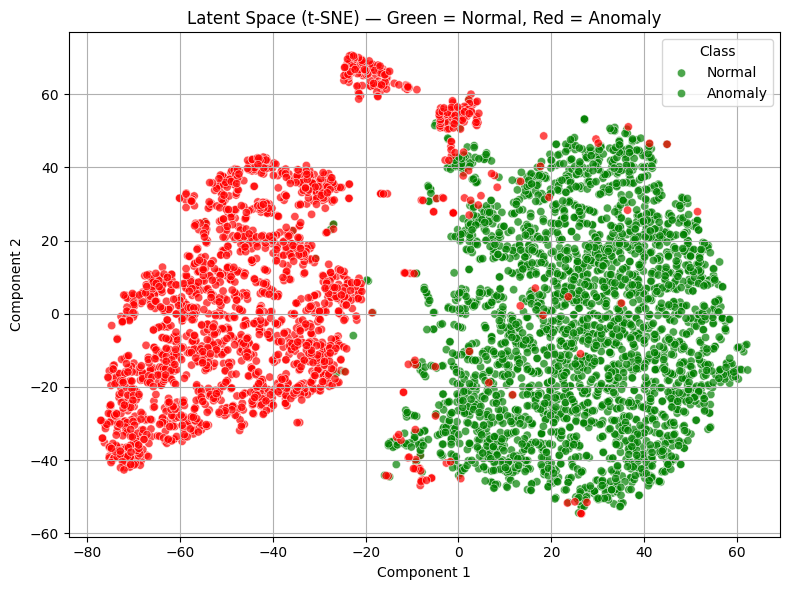

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

# Step 1: Extract μ vectors from encoder
model.eval()
with torch.no_grad():
    mu, _ = model.encode(X_all_tensor.to(device))
    mu = mu.cpu().numpy()

# Step 2: Apply t-SNE to reduce to 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=0)
mu_2d = tsne.fit_transform(mu)

# Step 3: Plot with seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(x=mu_2d[:, 0], y=mu_2d[:, 1], hue=y_binary, palette=["green", "red"], alpha=0.7)
plt.title("Latent Space (t-SNE) — Green = Normal, Red = Anomaly")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Class", labels=["Normal", "Anomaly"])
plt.grid(True)
plt.tight_layout()
plt.show()

**Confusion Matrix**

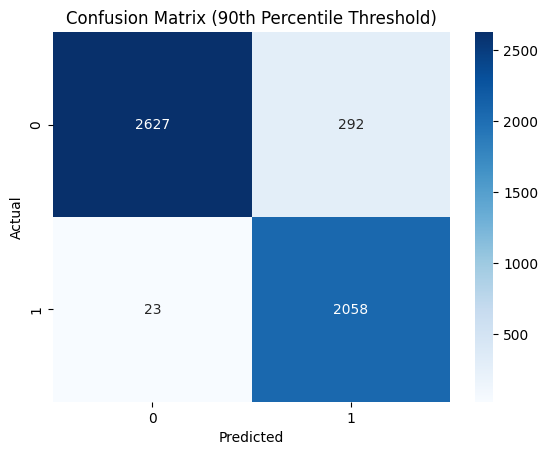

In [ ]:


threshold = np.percentile(recon_errors[y_binary == 0], 90)
y_pred = (recon_errors > threshold).astype(int)
cm = confusion_matrix(y_binary, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (90th Percentile Threshold)")
plt.show()


**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_binary, y_pred, target_names=["Normal", "Anomaly"]))


              precision    recall  f1-score   support

      Normal       0.99      0.90      0.94      2919
     Anomaly       0.88      0.99      0.93      2081

    accuracy                           0.94      5000
   macro avg       0.93      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



##**Conclusion**
In this project, I implemented a Variational Autoencoder (VAE) for unsupervised anomaly detection in ECG signals. The model effectively reconstructed normal signals and detected anomalies based on reconstruction error. The results showed strong performance, with an AUC of 0.97 and an F1-score of 0.94, demonstrating the potential of VAEs for anomaly detection in healthcare data.